# VHH HEFT predictions

Interactive notebook for **$W^\pm HH$** and **$ZHH$** using bundled JSON inputs (`pdf_alpha_s_covariance.json`, `scale_coefficients.json`).

| Section | Purpose |
|---------|---------|
| **Setup** | Load analysis for a process / energy |
| **Spot check** | Print $\sigma_{\mathrm{LO}}$, $\sigma_{\mathrm{NNLO}}$, $K$ at chosen $\kappa$ |
| **Scans & plots** | $\kappa$ scans with PDF+$\alpha_s$ and scale bands (saved under `plots/`) |
| **SM enhancement** | $\sigma_{\mathrm{LO,NNLO}}/\sigma_{\mathrm{LO,NNLO}}^{\mathrm{SM}}$ vs $\kappa$ (optional) |

Run from the `Package/` directory.

In [2]:
import sys
from pathlib import Path

PACKAGE_ROOT = Path('.').resolve()
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

import matplotlib.pyplot as plt
from vhh_predict import (
    collect_simulation_scan_points,
    format_prediction,
    load_analysis,
    predict,
    plots_dir,
    resolve_scan_axis,
    scan,
    scan_axes,
    scan_sm_enhancement,
    simulation_scan_arrays,
)
from vhh_predict.plots import X_LABELS, plot_kfactor_only, plot_sigma_nnlo_and_kfactor, plot_sm_enhancement

PLOTS_DIR = plots_dir()
PLOTS_DIR.mkdir(exist_ok=True)

## 1. Configuration

Set the options in the next cell, then run it once per session.

| Option | Description |
|--------|-------------|
| `PROCESS` | `WplusHH`, `WminusHH`, or `ZHH` |
| `ENERGY_TEV` | `13.6` or `14.0` (must match bundled `data/{Process}/…`) |
| `KAPPA` | Fixed κ point for spot check; see tuple layout below |
| `UNCERTAINTIES_AS_PERCENT` | Print scale/PDF bands as `%` in section 2 |
| `SAVE_PLOTS` | Write PNG figures to `plots/` |
| `SIGMA_INSET` | Zoom inset on σ panel in section 4 (left 1% of scan range) |
| `COMPARE_SIMULATION` | Compare to bundled MadGraph `.out` files in `data/{Process}/{energy}/Simulation/` (sections 2 & 4) |
| `PLOT_SM_ENHANCEMENT` | Run section 6 (σ/σ_SM scan) |

**κ tuple layout** (order matters):

| Process | `KAPPA` | Default for omitted component |
|---------|---------|-------------------------------|
| `WplusHH`, `WminusHH` | `(κ_λ, κ_W, κ_2W)` | — |
| `ZHH` | `(κ_λ, κ_Z, κ_2Z)` or `(κ_λ, κ_Z, κ_2Z, κ_t)` | `κ_t = 1` if omitted |

**Scan axes** (`scan_axis` in section 4; also used in section 6):

| Process | `scan_axes(PROCESS)` |
|---------|----------------------|
| `ZHH` | `kappa_lambda`, `kappa_z`, `kappa_2z`, `kappa_t` |
| `W±` | `kappa_lambda`, `kappa_w`, `kappa_2w` |

Aliases: `kappa_kt` → `kappa_t` (ZHH only).

In [5]:
PROCESS = 'ZHH'        # 'WplusHH' | 'WminusHH' | 'ZHH'
ENERGY_TEV = 14.0      # 13.6 or 14.0

# κ at the spot-check point (section 2):
#   W±:  (kappa_lambda, kappa_w, kappa_2w)
#   ZHH: (kappa_lambda, kappa_z, kappa_2z)  or add kappa_t as 4th element
KAPPA = (3.0, 1.0, 1.0)

UNCERTAINTIES_AS_PERCENT = True
SAVE_PLOTS = True
SIGMA_INSET = True             # section 4: zoom inset on σ panel
COMPARE_SIMULATION = True
PLOT_SM_ENHANCEMENT = True

analysis = load_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f'Process: {PROCESS} @ {ENERGY_TEV} TeV')
print(f'Available scan axes: {", ".join(scan_axes(PROCESS))}')

Process: ZHH @ 14.0 TeV
Available scan axes: kappa_lambda, kappa_z, kappa_2z, kappa_t


## 2. Spot check — print prediction

In [6]:
print(format_prediction(
    analysis,
    KAPPA,
    as_percent=UNCERTAINTIES_AS_PERCENT,
    compare_simulation=COMPARE_SIMULATION,
))

ZHH @ 14.0 TeV  κ=(3, 1, 1, 1)
  σ_LO   HEFT 0.734171  +0.81%/-1.07% (scale)  ±2.01% (PDF+αs)
  σ_NNLO  HEFT 0.944590  +2.03%/-1.65% (scale)  ±1.95% (PDF+αs)
  K      HEFT 1.286607  +1.53%/-1.35% (scale)  ±2.80% (PDF+αs)
             sim 0.740306  (diff -0.829% vs HEFT)
             sim 0.948605  (diff -0.423% vs HEFT)
             sim 1.28137  (diff +0.409% vs HEFT)


## 3. Structured output

In [10]:
p = predict(analysis, KAPPA)
{
    'sigma_LO': p.sigma_lo,
    'sigma_NNLO': p.sigma_nnlo,
    'K': p.k_factor,
    'sigma_NNLO_pdfas': p.sigma_nnlo_pdfas,
    'sigma_NNLO_scale_up': p.sigma_nnlo_scale_up,
    'sigma_NNLO_scale_down': p.sigma_nnlo_scale_down,
}

{'sigma_LO': 0.30550148356999995,
 'sigma_NNLO': 0.41733302273100004,
 'K': 1.3660589069950488,
 'sigma_NNLO_pdfas': 0.0078804499933547,
 'sigma_NNLO_scale_up': 0.014290329209833641,
 'sigma_NNLO_scale_down': 0.011224592108867615}

## 4. κ scan — σ$_{\mathrm{NNLO}}$ + $K$ (two panels)

Vary one κ component while the others stay fixed at `KAPPA` (with `κ_t=1` appended for ZHH if omitted).

- **Top panel:** σ$_{\mathrm{NNLO}}$ with PDF+α$_s$ (blue) and 7-point scale envelope (red hatch). Set `SIGMA_INSET = True` in section 1 for a zoom inset on the left 1% of the scan range.
- **Bottom panel:** $K = \sigma_{\mathrm{NNLO}}/\sigma_{\mathrm{LO}}$.
- Set `show_k_uncertainty=True` in the plot call to draw $K$ uncertainty bands.
- With `COMPARE_SIMULATION=True`, matching MadGraph central values are overlaid as orange circles.

Overlaying 1 simulation point(s) on scan plot


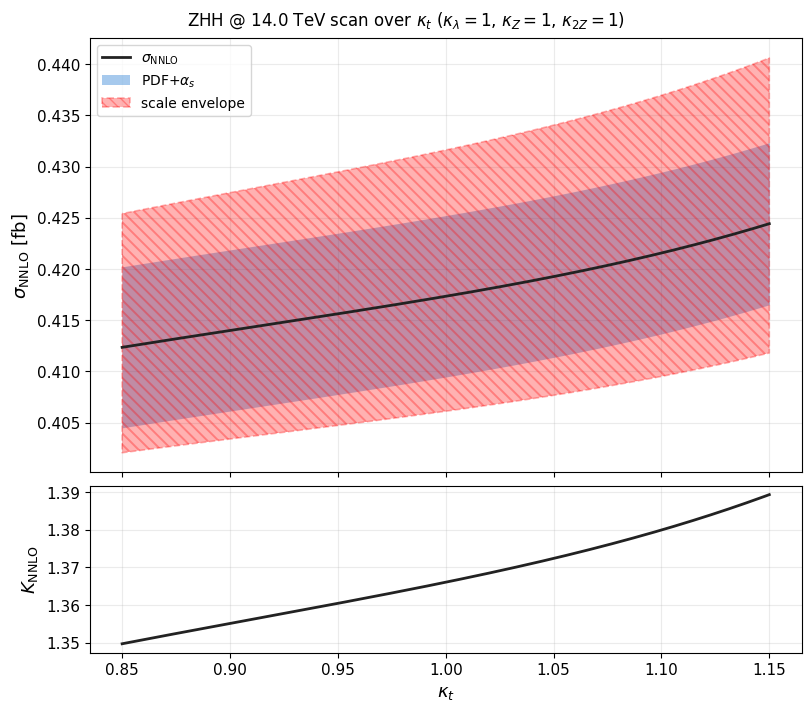

Saved /Users/michalryczkowski/Documents/Projects/Current/Gioia/Code_21_04/pphhV/Package/plots/ZHH_14.0TeV_scan_kappa_t.png


In [11]:
fixed = list(KAPPA)
if PROCESS == 'ZHH' and len(fixed) == 3:
    fixed.append(1.0)

# --- scan settings (must be one of scan_axes(PROCESS)) ---
scan_axis = 'kappa_t'
scan_vmin, scan_vmax = 0.85, 1.15
scan_n_points = 400

_, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
scan_axis_label = X_LABELS[scan_x_key]

scan_data = scan(
    analysis,
    axis=scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    n_points=scan_n_points,
    fixed_kappa=tuple(fixed),
)

sim_scan = None
if COMPARE_SIMULATION:
    sim_points = collect_simulation_scan_points(
        PROCESS,
        ENERGY_TEV,
        scan_axis,
        fixed_kappa=tuple(fixed),
        vmin=scan_vmin,
        vmax=scan_vmax,
    )
    sim_scan = simulation_scan_arrays(sim_points)
    if len(sim_scan['x']):
        print(f'Overlaying {len(sim_scan["x"])} simulation point(s) on scan plot')

_scan_idx, _ = resolve_scan_axis(PROCESS, scan_axis)
if PROCESS == 'ZHH':
    _kappa_names = [r'\lambda', 'Z', r'2Z', 't']
    fixed_title = ', '.join(
        rf'$\kappa_{{{_kappa_names[i]}}}={fixed[i]:g}$'
        for i in range(4)
        if i != _scan_idx
    )
else:
    _kappa_names = [r'\lambda', 'W', r'2W']
    fixed_title = ', '.join(
        rf'$\kappa_{{{_kappa_names[i]}}}={fixed[i]:g}$'
        for i in range(3)
        if i != _scan_idx
    )

sigma_k_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_scan_{scan_x_key}.png'
plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=f'{PROCESS} @ {ENERGY_TEV} TeV scan over {scan_axis_label} ({fixed_title})',
    nnlo_label=nn_label,
    show_k_uncertainty=False,
    sigma_inset=False,
    #sim_scan=sim_scan,
    output=sigma_k_path,
    save=SAVE_PLOTS,
)
plt.show()
if SAVE_PLOTS:
    print(f'Saved {sigma_k_path}')

## 5. K-factor only

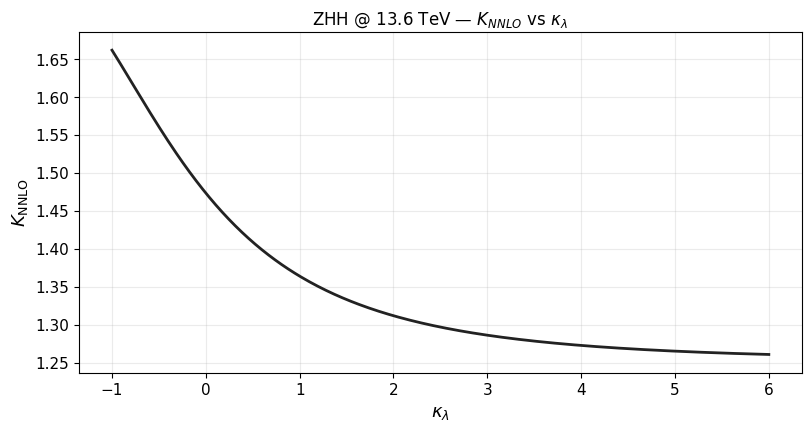

Saved /Users/michalryczkowski/Documents/Projects/Current/Gioia/Code_21_04/pphhV/Package/plots/ZHH_13.6TeV_K.png


In [7]:
k_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_K_{scan_x_key}.png'
plot_kfactor_only(
    scan_data,
    title=f'{PROCESS} @ {ENERGY_TEV} TeV — $K_{{{nn_label}}}$ vs {scan_axis_label}',
    nnlo_label=nn_label,
    show_uncertainty=False,
    output=k_path,
    save=SAVE_PLOTS,
)
plt.show()
if SAVE_PLOTS:
    print(f'Saved {k_path}')

## 6. SM enhancement — $\sigma/\sigma_{\mathrm{SM}}$ (LO and NNLO)

HEFT cross section relative to the SM point $\kappa=(1,1,1)$ for W$^\pm$HH or $(1,1,1,1)$ for ZHH.

SM reference @ ZHH 13.6 TeV: σ_LO=0.290695 fb, σ_NNLO=0.396465 fb


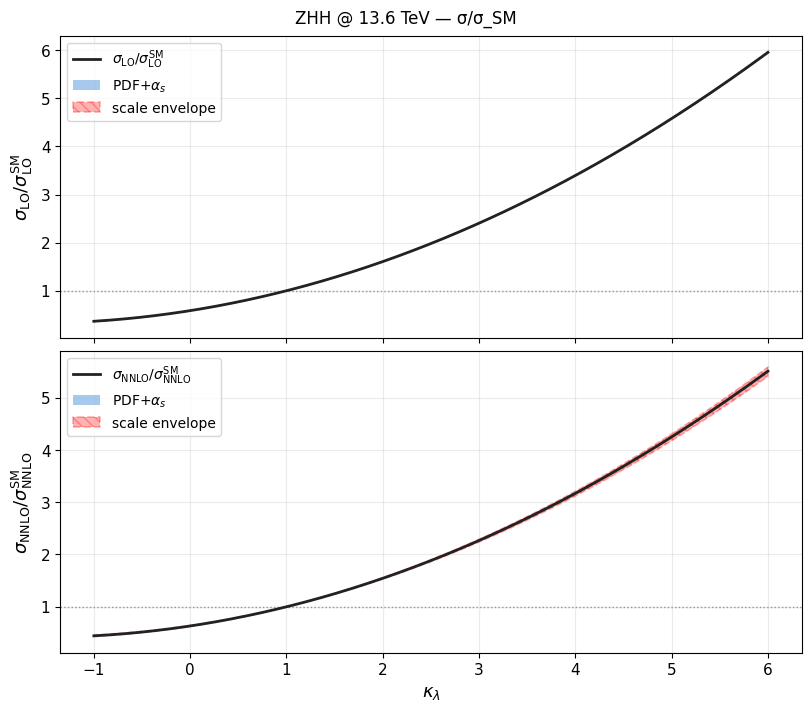

Saved /Users/michalryczkowski/Documents/Projects/Current/Gioia/Code_21_04/pphhV/Package/plots/ZHH_13.6TeV_SM_enhancement.png


In [8]:
if PLOT_SM_ENHANCEMENT:
    enh_scan = scan_sm_enhancement(
        analysis,
        axis='kappa_lambda',
        vmin=-1.0,
        vmax=6.0,
        n_points=400,
        fixed_kappa=tuple(fixed),
    )
    sm_lo = float(enh_scan['sigma_lo_sm'][0])
    sm_nnlo = float(enh_scan['sigma_nnlo_sm'][0])
    print(f'SM reference @ {PROCESS} {ENERGY_TEV} TeV: σ_LO={sm_lo:.6f} fb, σ_{nn_label}={sm_nnlo:.6f} fb')

    enh_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_SM_enhancement.png'
    plot_sm_enhancement(
        enh_scan,
        title=f'{PROCESS} @ {ENERGY_TEV} TeV — σ/σ_SM',
        nnlo_label=nn_label,
        output=enh_path,
        save=SAVE_PLOTS,
    )
    plt.show()
    if SAVE_PLOTS:
        print(f'Saved {enh_path}')